In [1]:
# set device variable

import torch

if torch.cuda.is_available():
    device = "cuda"
else:
    device = "cpu"

print(f"\nTorch is available with 'device={device}'.")


Torch is available with 'device=cpu'.


# MACE

For the last three years, [MACE](https://mace-docs.readthedocs.io/en/latest/) has been our MLIP of choice. The materials science community is very active in developing new features, tailoring data sets and foundation MLIPs (FMLIPs), and providing benchmarks on different systems. In this notebook (and, to be honest, daily life), I freely mix the terms "model" and "MLIP" while sometimes regressing to "network", "force field" etc. - please ask if the terminology is unclear.

In the practical session we mainly focus on MACE, instead of going through typical ML tutorial tasks like regression, since there are a million and one great resources available online, for example at [scikit-learn](https://scikit-learn.org/stable/).

Up to a couple of years ago, we would have started this session by training a model on our data from scratch, but this is not the most sensible approach anymore for many applications. Instead, we will first look into some of our prepared data and then use an FMLIP.


## Data first

Almost no matter the task, it is sensible to start by looking at the data, if it is already available. For this workshop, we use the dataset published on [Zenodo](https://zenodo.org/records/2603918) with the manuscript [*Parallel Multistream Training of High-Dimensional Neural Network Potentials*](https://doi.org/10.1021/acs.jctc.8b01092) by Christoph Dellago and coworkers.

If you cannot use an existing dataset, you still typically start there. This data generation can also benefit from the availability of FMLIPs.

In [2]:
import pathlib
import ase.io

data_path = pathlib.Path.cwd().parents[1] / "data" / "mace_training"

# this is the held-out test data not used in **any** training
test_set = ase.io.read(data_path / "data_all_test.extxyz", index=":")
print(f"The test set contains {len(test_set)} structures.")

The test set contains 379 structures.


It is not sensible to aim for a one-size-fits-all error to gauge if a model is performing well on given data. For example, the distribution of forces encountered when generating data using molecular dynamics (MD, we'll discuss that later today) is way narrower then for evolutionary searches (this we will not use in the workshop, but I'll talk about it at the end of today).

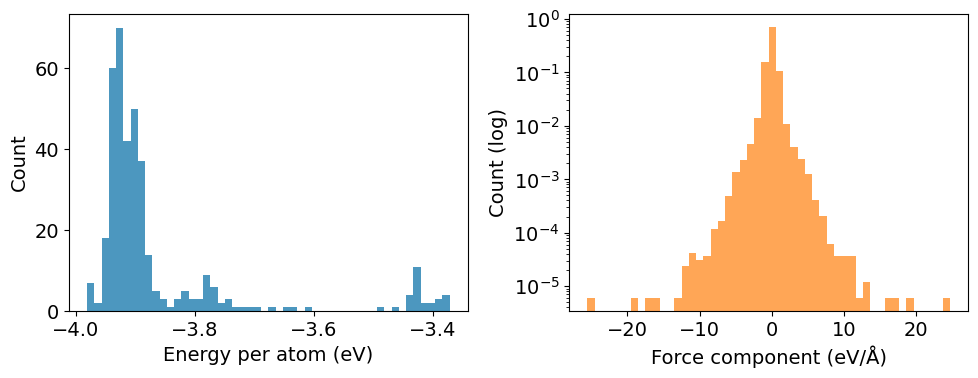

In [3]:
import matplotlib
import matplotlib.pyplot as plt

matplotlib.style.use("default")
matplotlib.rcParams["font.size"] = 14.0
matplotlib.rcParams["legend.fontsize"] = 12.0

plt.style.use("tableau-colorblind10")

import numpy as np
from scipy.stats import gaussian_kde

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

ref_energies = np.array([atoms.info["REF_energy"] / len(atoms) for atoms in test_set])
ref_energies = np.array(ref_energies)
ref_forces = np.array(np.concatenate([atoms.arrays["REF_forces"].flatten() for atoms in test_set]))

axes[0].hist(ref_energies, bins=50, color='C0', alpha=0.7)
axes[0].set_xlabel('Energy per atom (eV)')
axes[0].set_ylabel('Count')

axes[1].hist(ref_forces, bins=50, color='C1', alpha=0.7, density=True)
axes[1].set_yscale("log")
axes[1].set_xlabel('Force component (eV/Å)')
axes[1].set_ylabel('Count (log)')

plt.tight_layout()
plt.show()

## Model second

Do we even need a new MLIP? Let us first try one of the earlier foundation models: [MP0](https://mace-docs.readthedocs.io/en/latest/guide/foundation_models.html#foundation-models).

If you work on a CPU and find that the evaluation takes too long, you can load the predictions from files.

From the way that Jupyter notebooks are typically used, you will encounter a lot of duplicated code. That said, when preparing a workshop or software to ship, it is sensible to define functions.

In [4]:
import matplotlib
import matplotlib.pyplot as plt

matplotlib.style.use("default")
matplotlib.rcParams["font.size"] = 14.0
matplotlib.rcParams["legend.fontsize"] = 12.0

plt.style.use("tableau-colorblind10")

from mace.calculators import MACECalculator, mace_mp
from tqdm.auto import tqdm
from scipy.stats import spearmanr
from sklearn.metrics import root_mean_squared_error


# use a given MACECalculator (= model) to evaluate data
def evaluate_with_mace(calc: MACECalculator, eval_data: str or pathtlib.Path):
    pred_energies = []
    pred_forces = []
    
    for atoms in tqdm(eval_data):
        atoms.calc = calc
        pred_energies.append(atoms.get_potential_energy() / len(atoms))
        pred_forces.append(atoms.get_forces().flatten())

    pred_energies = np.array(pred_energies)
    pred_forces = np.concatenate(pred_forces)

    return pred_energies, pred_forces


# visualize the evaluation results
def make_pareto_plots(
    ref_energies: list[float],
    ref_forces: list[float],
    pred_energies: list[float],
    pred_forces: list[float],
    save_to_this_file: str = None,
    dpi: int = 150,
):
    fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    
    for ax, ref, pred, label in zip(
        axes,
        [ref_energies, ref_forces],
        [pred_energies, pred_forces],
        [r"$E_{\mathrm{XYZ}}$ (eV/atom)", r"$f_{\mathrm{XYZ}}$ (eV/Å)"],
    ):
        lim = [min(ref.min(), pred.min()), max(ref.max(), pred.max())]
        ax.plot(lim, lim, '--', lw=1.5, color="C0")
        ax.scatter(ref, pred, alpha=0.3, s=50, marker="x", color="C1")
        ax.set_xlabel(label.replace("XYZ", "DFT"))
        ax.set_ylabel(label.replace("XYZ", "MLIP"))
    
        rmse = root_mean_squared_error(ref, pred)
        rho, _ = spearmanr(ref, pred)
        ax.text(
            0.05, 0.95, f'RMSE = {rmse:.4f}\n' + r"$\rho_{\mathrm{S}}$" + f" = {rho:.4f}", transform=ax.transAxes,
            fontsize=12, va='top', ha='left',
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.7)
        )

        plt.tight_layout()
        
        if save_to_this_file is not None:
            plt.savefig(save_to_this_file, dpi=dpi)

    return fig, axes

/Users/rwanzenboeck/Documents/theochem/workshops/aarhus-dft-ml-workshop-2026/.venv/lib/python3.12/site-packages/e3nn/o3/_wigner.py:10: UserWarning: Environment variable TORCH_FORCE_NO_WEIGHTS_ONLY_LOAD detected, since the`weights_only` argument was not explicitly passed to `torch.load`, forcing weights_only=False.
  _Jd, _W3j_flat, _W3j_indices = torch.load(os.path.join(os.path.dirname(__file__), 'constants.pt'))


cuequivariance or cuequivariance_torch is not available. Cuequivariance acceleration will be disabled.


Pareto plots for vanilla MP0 small on test data:


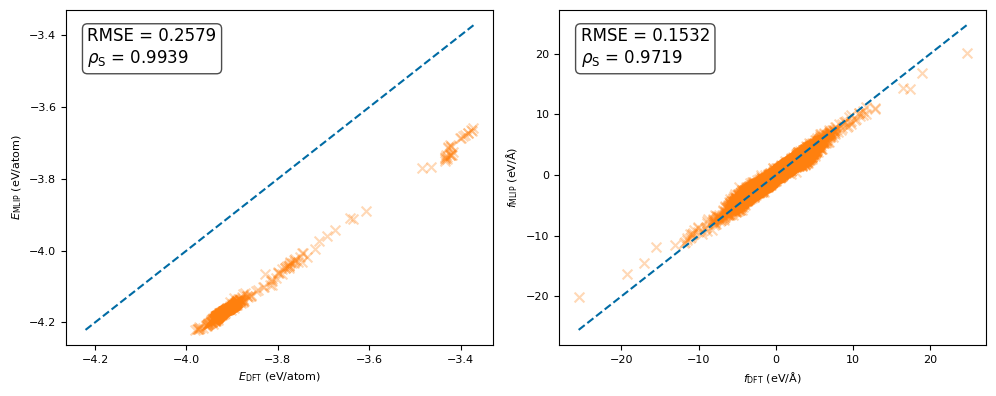

In [5]:
if device == "cuda":
    calc = mace_mp(model="small")
    pred_energies, pred_forces = evaluate_with_mace(calc, test_set)
else:
    load_path = pathlib.Path.cwd().parents[1] / "data" / "mace_training"
    pred_energies = np.load(load_path / f"mp0_test_eval_energies.npy")
    pred_forces = np.load(load_path / f"mp0_test_eval_forces.npy")

print("Pareto plots for vanilla MP0 small on test data:")

fig, axes = make_pareto_plots(
    ref_energies, ref_forces, pred_energies, pred_forces,
    save_to_this_file="mp0_small_test.png",
)

Judging from these plots, if the small MP0 were the only available FMLIP, we would need to either train our own model from scratch after all or fine-tune it. Since there exist a lot of alternatives, we will look into some in the tasks.

For now, we will train our own and fine-tune MP0.

#### Training a small model from scratch for comparison

In [3]:
import pathlib
import ase.io

load_path = pathlib.Path.cwd().parents[1] / "data" / "mace_training"
training_file = load_path / "data_all_train.extxyz"
validation_file = load_path / "data_all_valid.extxyz"
full_training_data = ase.io.read(training_file, index=":")
full_validation_data = ase.io.read(validation_file, index=":")

print(f"The available training data in '{str(training_file).split('/')[-1]}' contains {len(full_training_data)} structures in total.")
print(f"The separate validation data in '{str(validation_file).split('/')[-1]}' contains another {len(full_validation_data)} structures.")


The available training data in 'data_all_train.extxyz' contains 3026 structures in total.
The separate validation data in 'data_all_valid.extxyz' contains another 378 structures.


The full data set is clearly too large for our workshop, but also not needed to that extent for modern GNNs such as MACE.

Let us first use only 150 structures for training and 15 for validation.

In [42]:
from numpy.random import default_rng

# shuffle the indices, then select the first 150 for training
rng = default_rng(seed=1111)
training_indices = np.arange(len(full_training_data))
training_indices = rng.permutation(training_indices)
subset_training_indices = training_indices[:150]
ase.io.write("subset_train_150.extxyz", images=[full_training_data[i] for i in subset_training_indices])

# same for validation, selecting the first 15
rng = default_rng(seed=2222)
validation_indices = np.arange(len(full_validation_data))
validation_indices = rng.permutation(validation_indices)
subset_validation_indices = validation_indices[:15]
ase.io.write("subset_valid_15.extxyz", images=[full_validation_data[i] for i in subset_validation_indices])

In [13]:
"""
    In 'real life' we often submit such trainings to HPC clusters.
    The command looks very much the same.
    The `subprocess` call is one option for training in a notebook.
"""
import getpass
import os
import subprocess

plotflag = True  # set to False if you do not want MACE to create the images

# uncomment this if you want to log to wandb.ai (separate account needed)
# if "WANDB_API_KEY" not in os.environ:
#    os.environ["WANDB_API_KEY"] = getpass.getpass("Enter your W&B API key: ")

wandb_entity = "ralfwan"  # your wandb.ai username
wandb_project = "aarhus_workshop"  # I can add you to this project if you want that
wandb_name = "cu2s_smallest"

training_file = "subset_train_150.extxyz"
valid_file = "subset_valid_15.extxyz"

# these settings are as minimal as I dare to set them
result = subprocess.run([
    "mace_run_train",
    "--name=cu2s_smallest",
    f"--model_dir={str(pathlib.Path.cwd() / 'trained_models')}",
    f"--work_dir={str(pathlib.Path.cwd() / 'training_output')}",
    f"--train_file={training_file}",
    f"--valid_file={valid_file}",
    "--E0s=average",
    "--energy_key=REF_energy",
    "--forces_key=REF_forces",
    "--model=ScaleShiftMACE",
    "--hidden_irreps=16x0e + 16x1o",
    "--r_max=5.0",
    "--max_ell=1",
    "--num_interactions=1",
    "--batch_size=4",
    "--max_num_epochs=30",  # the amount of epochs is especially low
    f"--device={device}",
    "--seed=42",
    "--default_dtype=float32",
    "--ema",
    "--ema_decay=0.99",
    "--amsgrad",
    f"--plot={plotflag}",  # MACE will write figures to the work_dir if set to True
    # "--wandb",
    # f"--wandb_project={wandb_project}",
    # f"--wandb_entity={wandb_entity}",
    #f"--wandb_name={wandb_name}",
], capture_output=False)

/home/rwanzenboeck/Documents/theochem/workshops/202605_Aarhus/code/aarhus-dft-ml-workshop-2026/.venv/lib/python3.12/site-packages/e3nn/o3/_wigner.py:10: UserWarning: Environment variable TORCH_FORCE_NO_WEIGHTS_ONLY_LOAD detected, since the`weights_only` argument was not explicitly passed to `torch.load`, forcing weights_only=False.
  _Jd, _W3j_flat, _W3j_indices = torch.load(os.path.join(os.path.dirname(__file__), 'constants.pt'))


cuequivariance or cuequivariance_torch is not available. Cuequivariance acceleration will be disabled.
2026-05-01 14:45:49.158 INFO: ===========VERIFYING SETTINGS===========
2026-05-01 14:45:49.158 INFO: MACE version: 0.3.15
2026-05-01 14:45:49.205 INFO: CUDA version: 12.6, CUDA device: 0
2026-05-01 14:45:49.226 INFO: ===========LOADING INPUT DATA===========
2026-05-01 14:45:49.227 INFO: Using heads: ['Default']
2026-05-01 14:45:49.227 INFO: Using the key specifications to parse data:
2026-05-01 14:45:49.227 INFO: Default: KeySpecification(info_keys={'energy': 'REF_energy', 'stress': 'REF_stress', 'virials': 'REF_virials', 'dipole': 'dipole', 'head': 'head', 'elec_temp': 'elec_temp', 'total_charge': 'total_charge', 'polarizability': 'polarizability', 'total_spin': 'total_spin'}, arrays_keys={'forces': 'REF_forces', 'charges': 'REF_charges'})
2026-05-01 14:45:49.227 INFO: =============    Processing head Default     ===========
2026-05-01 14:45:49.281 INFO: Training set 1/1 [energy: 150

/home/rwanzenboeck/Documents/theochem/workshops/202605_Aarhus/code/aarhus-dft-ml-workshop-2026/miniforge3/envs/workshop_dependencies/lib/python3.12/ast.py:407: UserWarning: The TorchScript type system doesn't support instance-level annotations on empty non-base types in `__init__`. Instead, either 1) use a type annotation in the class body, or 2) wrap the type in `torch.jit.Attribute`.
  return visitor(node)
/home/rwanzenboeck/Documents/theochem/workshops/202605_Aarhus/code/aarhus-dft-ml-workshop-2026/miniforge3/envs/workshop_dependencies/lib/python3.12/ast.py:407: UserWarning: The TorchScript type system doesn't support instance-level annotations on empty non-base types in `__init__`. Instead, either 1) use a type annotation in the class body, or 2) wrap the type in `torch.jit.Attribute`.
  return visitor(node)
/home/rwanzenboeck/Documents/theochem/workshops/202605_Aarhus/code/aarhus-dft-ml-workshop-2026/miniforge3/envs/workshop_dependencies/lib/python3.12/ast.py:407: UserWarning: The

2026-05-01 14:45:50.316 INFO: Initial: head: Default, loss=10.87781620, RMSE_E_per_atom=  137.94 meV, RMSE_F=  845.89 meV / A
2026-05-01 14:45:50.816 INFO: Epoch 0: head: Default, loss=5.44639492, RMSE_E_per_atom=  153.92 meV, RMSE_F=  582.71 meV / A
2026-05-01 14:45:51.237 INFO: Epoch 1: head: Default, loss=1.67671454, RMSE_E_per_atom=  102.41 meV, RMSE_F=  338.01 meV / A
2026-05-01 14:45:51.674 INFO: Epoch 2: head: Default, loss=1.03035629, RMSE_E_per_atom=   87.00 meV, RMSE_F=  268.72 meV / A
2026-05-01 14:45:52.117 INFO: Epoch 3: head: Default, loss=0.75156409, RMSE_E_per_atom=   72.39 meV, RMSE_F=  227.07 meV / A
2026-05-01 14:45:52.587 INFO: Epoch 4: head: Default, loss=0.52066123, RMSE_E_per_atom=   56.83 meV, RMSE_F=  189.37 meV / A
2026-05-01 14:45:53.075 INFO: Epoch 5: head: Default, loss=0.41424668, RMSE_E_per_atom=   46.20 meV, RMSE_F=  167.95 meV / A
2026-05-01 14:45:53.510 INFO: Epoch 6: head: Default, loss=0.36082351, RMSE_E_per_atom=   38.69 meV, RMSE_F=  156.49 meV / A

/home/rwanzenboeck/Documents/theochem/workshops/202605_Aarhus/code/aarhus-dft-ml-workshop-2026/.venv/lib/python3.12/site-packages/mace/tools/checkpoint.py:187: UserWarning: Environment variable TORCH_FORCE_NO_WEIGHTS_ONLY_LOAD detected, since the`weights_only` argument was not explicitly passed to `torch.load`, forcing weights_only=False.
  torch.load(f=checkpoint_info.path, map_location=device),


2026-05-01 14:46:05.075 INFO: Evaluating valid_Default ...
2026-05-01 14:46:05.102 INFO: Error-table on TRAIN and VALID:
+---------------+---------------------+------------------+-------------------+
|  config_type  | RMSE E / meV / atom | RMSE F / meV / A | relative F RMSE % |
+---------------+---------------------+------------------+-------------------+
| train_Default |           17.3      |        125.7     |         14.60     |
| valid_Default |           19.9      |        123.0     |         14.58     |
+---------------+---------------------+------------------+-------------------+
2026-05-01 14:46:06.721 INFO: Done


Making the comparison to the foundation model a bit fairer, we adapt `r_max`, `max_ell`, and `max_num_epochs`.

We also activate the `swa` mode (different weights in the loss function) for the last 10 of 50 epochs.

/home/rwanzenboeck/Documents/theochem/workshops/202605_Aarhus/code/aarhus-dft-ml-workshop-2026/.venv/lib/python3.12/site-packages/mace/calculators/mace.py:199: UserWarning: Environment variable TORCH_FORCE_NO_WEIGHTS_ONLY_LOAD detected, since the`weights_only` argument was not explicitly passed to `torch.load`, forcing weights_only=False.
  torch.load(f=model_path, map_location=device)
/home/rwanzenboeck/Documents/theochem/workshops/202605_Aarhus/code/aarhus-dft-ml-workshop-2026/.venv/lib/python3.12/site-packages/mace/calculators/mace.py:199: UserWarning: 'torch.load' received a zip file that looks like a TorchScript archive dispatching to 'torch.jit.load' (call 'torch.jit.load' directly to silence this warning)
  torch.load(f=model_path, map_location=device)


  0%|          | 0/379 [00:00<?, ?it/s]

Pareto plots for our smallest from scratch model on test data:


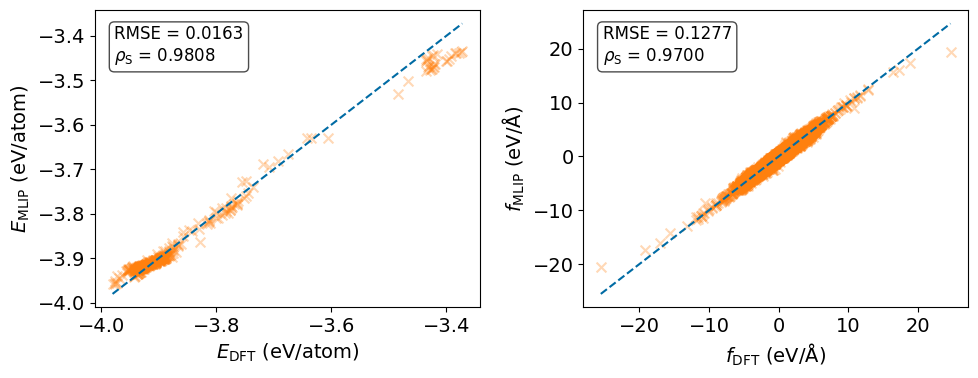

In [57]:
from mace.calculators import MACECalculator
from tqdm.auto import tqdm

calc = MACECalculator(model_paths=[str(pathlib.Path.cwd() / "trained_models" / "cu2s_smallest_compiled.model")])
pred_energies, pred_forces = evaluate_with_mace(calc, test_set)

print("Pareto plots for our smallest from scratch model on test data:")

fig, axes = make_pareto_plots(
    ref_energies, ref_forces, pred_energies, pred_forces,
    save_to_this_file="from_scratch_smallest.png",
)

In [9]:
"""
    In 'real life' we often submit such trainings to HPC clusters.
    The command looks very much the same.
    The `subprocess` call is one option for training in a notebook.
"""
import getpass
import os
import subprocess

plotflag = True  # set to False if you do not want MACE to create the images

# uncomment this if you want to log to wandb.ai (separate account needed)
# if "WANDB_API_KEY" not in os.environ:
#    os.environ["WANDB_API_KEY"] = getpass.getpass("Enter your W&B API key: ")

wandb_entity = "ralfwan"  # your wandb.ai username
wandb_project = "aarhus_workshop"  # I can add you to this project if you want that
wandb_name = "cu2s_small"

training_file = "subset_train_150.extxyz"
valid_file = "subset_valid_15.extxyz"

# these settings are as minimal as I dare to set them
result = subprocess.run([
    "mace_run_train",
    "--name=cu2s_small",
    f"--model_dir={str(pathlib.Path.cwd() / 'trained_models')}",
    f"--work_dir={str(pathlib.Path.cwd() / 'training_output')}",
    f"--train_file={training_file}",
    f"--valid_file={valid_file}",
    "--E0s=average",
    "--energy_key=REF_energy",
    "--forces_key=REF_forces",
    "--model=ScaleShiftMACE",
    "--hidden_irreps=16x0e + 16x1o",
    "--r_max=6.0",
    "--max_ell=2",
    "--num_interactions=2",
    "--batch_size=4",
    "--max_num_epochs=50",  # the amount of epochs is especially low
    f"--device={device}",
    "--seed=42",
    "--default_dtype=float32",
    "--ema",
    "--ema_decay=0.99",
    "--amsgrad",
    "--swa",
    "--start_swa=40",
    f"--plot={plotflag}",  # MACE will write figures to the work_dir if set to True
    # "--wandb",
    # f"--wandb_project={wandb_project}",
    # f"--wandb_entity={wandb_entity}",
    #f"--wandb_name={wandb_name}",
], capture_output=False)

/home/rwanzenboeck/Documents/theochem/workshops/202605_Aarhus/code/aarhus-dft-ml-workshop-2026/.venv/lib/python3.12/site-packages/e3nn/o3/_wigner.py:10: UserWarning: Environment variable TORCH_FORCE_NO_WEIGHTS_ONLY_LOAD detected, since the`weights_only` argument was not explicitly passed to `torch.load`, forcing weights_only=False.
  _Jd, _W3j_flat, _W3j_indices = torch.load(os.path.join(os.path.dirname(__file__), 'constants.pt'))


cuequivariance or cuequivariance_torch is not available. Cuequivariance acceleration will be disabled.
2026-05-01 16:41:47.997 INFO: ===========VERIFYING SETTINGS===========
2026-05-01 16:41:47.997 INFO: Stage Two is activated as start_stage_two was defined
2026-05-01 16:41:47.997 INFO: MACE version: 0.3.15
2026-05-01 16:41:48.045 INFO: CUDA version: 12.6, CUDA device: 0
2026-05-01 16:41:48.069 INFO: ===========LOADING INPUT DATA===========
2026-05-01 16:41:48.069 INFO: Using heads: ['Default']
2026-05-01 16:41:48.069 INFO: Using the key specifications to parse data:
2026-05-01 16:41:48.069 INFO: Default: KeySpecification(info_keys={'energy': 'REF_energy', 'stress': 'REF_stress', 'virials': 'REF_virials', 'dipole': 'dipole', 'head': 'head', 'elec_temp': 'elec_temp', 'total_charge': 'total_charge', 'polarizability': 'polarizability', 'total_spin': 'total_spin'}, arrays_keys={'forces': 'REF_forces', 'charges': 'REF_charges'})
2026-05-01 16:41:48.069 INFO: =============    Processing head

/home/rwanzenboeck/Documents/theochem/workshops/202605_Aarhus/code/aarhus-dft-ml-workshop-2026/miniforge3/envs/workshop_dependencies/lib/python3.12/ast.py:407: UserWarning: The TorchScript type system doesn't support instance-level annotations on empty non-base types in `__init__`. Instead, either 1) use a type annotation in the class body, or 2) wrap the type in `torch.jit.Attribute`.
  return visitor(node)
/home/rwanzenboeck/Documents/theochem/workshops/202605_Aarhus/code/aarhus-dft-ml-workshop-2026/miniforge3/envs/workshop_dependencies/lib/python3.12/ast.py:407: UserWarning: The TorchScript type system doesn't support instance-level annotations on empty non-base types in `__init__`. Instead, either 1) use a type annotation in the class body, or 2) wrap the type in `torch.jit.Attribute`.
  return visitor(node)
/home/rwanzenboeck/Documents/theochem/workshops/202605_Aarhus/code/aarhus-dft-ml-workshop-2026/miniforge3/envs/workshop_dependencies/lib/python3.12/ast.py:407: UserWarning: The

2026-05-01 16:41:49.142 INFO: ===========OPTIMIZER INFORMATION===========
2026-05-01 16:41:49.143 INFO: Using ADAM as parameter optimizer
2026-05-01 16:41:49.143 INFO: Batch size: 4
2026-05-01 16:41:49.143 INFO: Using Exponential Moving Average with decay: 0.99
2026-05-01 16:41:49.143 INFO: Number of gradient updates: 1875
2026-05-01 16:41:49.143 INFO: Learning rate: 0.01, weight decay: 5e-07
2026-05-01 16:41:49.143 INFO: WeightedEnergyForcesLoss(energy_weight=1.000, forces_weight=100.000)
2026-05-01 16:41:49.143 INFO: === Layer's learning rates ===
2026-05-01 16:41:49.143 INFO: Param group 0: lr = 0.01
2026-05-01 16:41:49.143 INFO: Param group 1: lr = 0.01
2026-05-01 16:41:49.143 INFO: Param group 2: lr = 0.01
2026-05-01 16:41:49.143 INFO: Param group 3: lr = 0.01
2026-05-01 16:41:49.143 INFO: Param group 4: lr = 0.01
2026-05-01 16:41:49.143 INFO: Stage Two (after 40 epochs) with loss function: WeightedEnergyForcesLoss(energy_weight=1000.000, forces_weight=100.000), with energy weight

/home/rwanzenboeck/Documents/theochem/workshops/202605_Aarhus/code/aarhus-dft-ml-workshop-2026/.venv/lib/python3.12/site-packages/mace/tools/checkpoint.py:187: UserWarning: Environment variable TORCH_FORCE_NO_WEIGHTS_ONLY_LOAD detected, since the`weights_only` argument was not explicitly passed to `torch.load`, forcing weights_only=False.
  torch.load(f=checkpoint_info.path, map_location=device),


2026-05-01 16:44:42.785 INFO: Computing metrics for training, validation, and test sets
2026-05-01 16:44:42.785 INFO: Skipping evaluation for heads: ['pt_head']
2026-05-01 16:44:42.785 INFO: Evaluating train_Default ...
2026-05-01 16:44:43.956 INFO: Evaluating valid_Default ...
2026-05-01 16:44:44.083 INFO: Error-table on TRAIN and VALID:
+---------------+---------------------+------------------+-------------------+
|  config_type  | RMSE E / meV / atom | RMSE F / meV / A | relative F RMSE % |
+---------------+---------------------+------------------+-------------------+
| train_Default |            7.7      |         72.9     |          8.47     |
| valid_Default |            8.7      |         69.7     |          8.26     |
+---------------+---------------------+------------------+-------------------+
2026-05-01 16:44:46.766 INFO: Loading checkpoint: /home/rwanzenboeck/Documents/theochem/workshops/202605_Aarhus/code/aarhus-dft-ml-workshop-2026/notebooks/MLIP/training_output/checkpoin

/home/rwanzenboeck/Documents/theochem/workshops/202605_Aarhus/code/aarhus-dft-ml-workshop-2026/.venv/lib/python3.12/site-packages/mace/tools/checkpoint.py:187: UserWarning: Environment variable TORCH_FORCE_NO_WEIGHTS_ONLY_LOAD detected, since the`weights_only` argument was not explicitly passed to `torch.load`, forcing weights_only=False.
  torch.load(f=checkpoint_info.path, map_location=device),
/home/rwanzenboeck/Documents/theochem/workshops/202605_Aarhus/code/aarhus-dft-ml-workshop-2026/miniforge3/envs/workshop_dependencies/lib/python3.12/ast.py:407: UserWarning: The TorchScript type system doesn't support instance-level annotations on empty non-base types in `__init__`. Instead, either 1) use a type annotation in the class body, or 2) wrap the type in `torch.jit.Attribute`.
  return visitor(node)


2026-05-01 16:44:47.243 INFO: Computing metrics for training, validation, and test sets
2026-05-01 16:44:47.243 INFO: Skipping evaluation for heads: ['pt_head']
2026-05-01 16:44:47.243 INFO: Evaluating train_Default ...
2026-05-01 16:44:48.455 INFO: Evaluating valid_Default ...
2026-05-01 16:44:48.569 INFO: Error-table on TRAIN and VALID:
+---------------+---------------------+------------------+-------------------+
|  config_type  | RMSE E / meV / atom | RMSE F / meV / A | relative F RMSE % |
+---------------+---------------------+------------------+-------------------+
| train_Default |            3.7      |         71.2     |          7.99     |
| valid_Default |            3.3      |         67.7     |          8.02     |
+---------------+---------------------+------------------+-------------------+
2026-05-01 16:44:50.917 INFO: Done


/home/rwanzenboeck/Documents/theochem/workshops/202605_Aarhus/code/aarhus-dft-ml-workshop-2026/.venv/lib/python3.12/site-packages/mace/calculators/mace.py:199: UserWarning: Environment variable TORCH_FORCE_NO_WEIGHTS_ONLY_LOAD detected, since the`weights_only` argument was not explicitly passed to `torch.load`, forcing weights_only=False.
  torch.load(f=model_path, map_location=device)
/home/rwanzenboeck/Documents/theochem/workshops/202605_Aarhus/code/aarhus-dft-ml-workshop-2026/.venv/lib/python3.12/site-packages/mace/calculators/mace.py:199: UserWarning: 'torch.load' received a zip file that looks like a TorchScript archive dispatching to 'torch.jit.load' (call 'torch.jit.load' directly to silence this warning)
  torch.load(f=model_path, map_location=device)


  0%|          | 0/379 [00:00<?, ?it/s]

Pareto plots for the small from scratch model on test data:


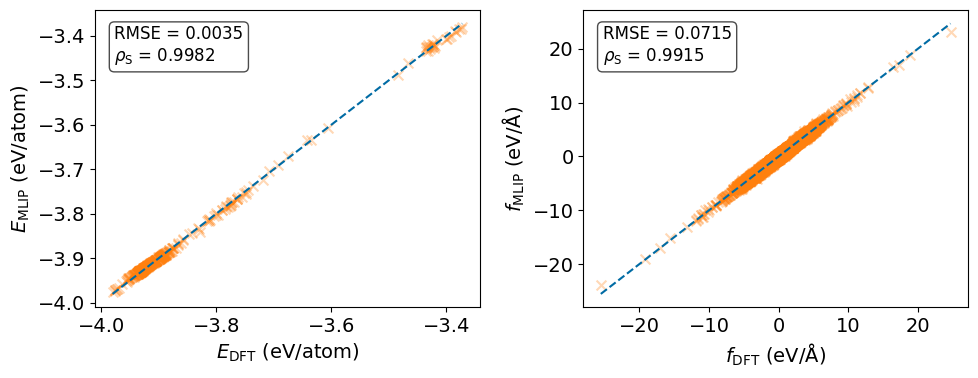

In [58]:
from mace.calculators import MACECalculator
from tqdm.auto import tqdm

calc = MACECalculator(model_paths=[str(pathlib.Path.cwd() / "trained_models" / "cu2s_small_stagetwo_compiled.model")])
pred_energies, pred_forces = evaluate_with_mace(calc, test_set)

print("Pareto plots for the small from scratch model on test data:")

fig, axes = make_pareto_plots(
    ref_energies, ref_forces, pred_energies, pred_forces,
    save_to_this_file="from_scratch_small.png",
)

What if we now instead fine-tune the foundation model?

The (computationally) cheapest approach to this is freezing most of the parameters.

In [12]:
import getpass
import os
import subprocess

# uncomment this if you want to log to wandb.ai (separate account needed)
if "WANDB_API_KEY" not in os.environ:
   os.environ["WANDB_API_KEY"] = getpass.getpass("Enter your W&B API key: ")

wandb_entity = "ralfwan"  # your wandb.ai username
wandb_project = "aarhus_workshop"  # I can add you to this project if you want that
wandb_name = "mp0_tuned_150_50epochs"

training_file = "subset_train_150.extxyz"
valid_file = "subset_valid_15.extxyz"

result = subprocess.run([
    "mace_run_train",
    f"--name={wandb_name}",
    f"--model_dir={str(pathlib.Path.cwd() / 'trained_models')}",
    f"--work_dir={str(pathlib.Path.cwd() / 'training_output')}",
    f"--train_file={training_file}",
    f"--valid_file={valid_file}",
    "--foundation_model=small",
    "--E0s=foundation",
    "--freeze=6",  # freeze all weights except the readouts
    "--multiheads_finetuning=false",
    "--energy_key=REF_energy",
    "--forces_key=REF_forces",
    "--batch_size=4",
    "--max_num_epochs=50",
    f"--device={device}",
    "--seed=42",
    "--default_dtype=float32",
    "--swa",
    "--start_swa=40",
    "--ema",
    "--ema_decay=0.99",
    "--amsgrad",
    "--wandb",
    f"--wandb_project={wandb_project}",
    f"--wandb_entity={wandb_entity}",
    f"--wandb_name={wandb_name}"
], capture_output=False)

Enter your W&B API key:  ········


/home/rwanzenboeck/Documents/theochem/workshops/202605_Aarhus/code/aarhus-dft-ml-workshop-2026/.venv/lib/python3.12/site-packages/e3nn/o3/_wigner.py:10: UserWarning: Environment variable TORCH_FORCE_NO_WEIGHTS_ONLY_LOAD detected, since the`weights_only` argument was not explicitly passed to `torch.load`, forcing weights_only=False.
  _Jd, _W3j_flat, _W3j_indices = torch.load(os.path.join(os.path.dirname(__file__), 'constants.pt'))


cuequivariance or cuequivariance_torch is not available. Cuequivariance acceleration will be disabled.
2026-05-01 18:18:34.316 INFO: ===========VERIFYING SETTINGS===========
2026-05-01 18:18:34.316 INFO: Stage Two is activated as start_stage_two was defined
2026-05-01 18:18:34.316 INFO: MACE version: 0.3.15
2026-05-01 18:18:34.366 INFO: CUDA version: 12.6, CUDA device: 0
2026-05-01 18:18:34.389 INFO: Using foundation model mace small as initial checkpoint.


/home/rwanzenboeck/Documents/theochem/workshops/202605_Aarhus/code/aarhus-dft-ml-workshop-2026/.venv/lib/python3.12/site-packages/mace/calculators/mace.py:199: UserWarning: Environment variable TORCH_FORCE_NO_WEIGHTS_ONLY_LOAD detected, since the`weights_only` argument was not explicitly passed to `torch.load`, forcing weights_only=False.
  torch.load(f=model_path, map_location=device)


Using Materials Project MACE for MACECalculator with /home/rwanzenboeck/.cache/mace/20231210mace128L0_energy_epoch249model
Using float32 for MACECalculator, which is faster but less accurate. Recommended for MD. Use float64 for geometry optimization.
2026-05-01 18:18:34.541 INFO: CUDA version: 12.6, CUDA device: 0
2026-05-01 18:18:34.543 INFO: Using head Default out of  ['Default']
2026-05-01 18:18:34.543 WARNING: Default dtype float32 does not match model dtype float64, converting models to float32.
2026-05-01 18:18:34.549 INFO: ===========LOADING INPUT DATA===========
2026-05-01 18:18:34.549 INFO: Using heads: ['Default']
2026-05-01 18:18:34.549 INFO: Using the key specifications to parse data:
2026-05-01 18:18:34.549 INFO: Default: KeySpecification(info_keys={'energy': 'REF_energy', 'stress': 'REF_stress', 'virials': 'REF_virials', 'dipole': 'dipole', 'head': 'head', 'elec_temp': 'elec_temp', 'total_charge': 'total_charge', 'polarizability': 'polarizability', 'total_spin': 'total_sp

...

2026-05-01 18:18:37.812 INFO: Using gradient clipping with tolerance=10.000
2026-05-01 18:18:37.813 INFO: 
2026-05-01 18:18:37.813 INFO: ===========TRAINING===========
2026-05-01 18:18:37.813 INFO: Started training, reporting errors on validation set
2026-05-01 18:18:37.813 INFO: Loss metrics on validation set
2026-05-01 18:18:38.434 INFO: Initial: head: Default, loss=0.31642190, RMSE_E_per_atom=  255.54 meV, RMSE_F=  139.65 meV / A
2026-05-01 18:18:49.015 INFO: Epoch 0: head: Default, loss=0.22089949, RMSE_E_per_atom=  167.42 meV, RMSE_F=  117.12 meV / A
2026-05-01 18:18:57.107 INFO: Epoch 1: head: Default, loss=0.18938154, RMSE_E_per_atom=   60.05 meV, RMSE_F=  110.00 meV / A
2026-05-01 18:19:04.662 INFO: Epoch 2: head: Default, loss=0.17072608, RMSE_E_per_atom=    8.86 meV, RMSE_F=  105.12 meV / A
2026-05-01 18:19:12.201 INFO: Epoch 3: head: Default, loss=0.16114210, RMSE_E_per_atom=    9.99 meV, RMSE_F=  102.34 meV / A
2026-05-01 18:19:19.736 INFO: Epoch 4: head: Default, loss=0.15

/home/rwanzenboeck/Documents/theochem/workshops/202605_Aarhus/code/aarhus-dft-ml-workshop-2026/.venv/lib/python3.12/site-packages/mace/tools/checkpoint.py:187: UserWarning: Environment variable TORCH_FORCE_NO_WEIGHTS_ONLY_LOAD detected, since the`weights_only` argument was not explicitly passed to `torch.load`, forcing weights_only=False.
  torch.load(f=checkpoint_info.path, map_location=device),
/home/rwanzenboeck/Documents/theochem/workshops/202605_Aarhus/code/aarhus-dft-ml-workshop-2026/miniforge3/envs/workshop_dependencies/lib/python3.12/ast.py:407: UserWarning: The TorchScript type system doesn't support instance-level annotations on empty non-base types in `__init__`. Instead, either 1) use a type annotation in the class body, or 2) wrap the type in `torch.jit.Attribute`.
  return visitor(node)


2026-05-01 18:25:09.006 INFO: Computing metrics for training, validation, and test sets
2026-05-01 18:25:09.006 INFO: Skipping evaluation for heads: ['pt_head']
2026-05-01 18:25:09.006 INFO: Evaluating train_Default ...
2026-05-01 18:25:11.479 INFO: Evaluating valid_Default ...
2026-05-01 18:25:11.764 INFO: Error-table on TRAIN and VALID:
+---------------+---------------------+------------------+-------------------+
|  config_type  | RMSE E / meV / atom | RMSE F / meV / A | relative F RMSE % |
+---------------+---------------------+------------------+-------------------+
| train_Default |           11.0      |         89.3     |         10.38     |
| valid_Default |           11.3      |         82.6     |          9.79     |
+---------------+---------------------+------------------+-------------------+
2026-05-01 18:25:15.758 INFO: Loading checkpoint: /home/rwanzenboeck/Documents/theochem/workshops/202605_Aarhus/code/aarhus-dft-ml-workshop-2026/notebooks/MLIP/training_output/checkpoin

/home/rwanzenboeck/Documents/theochem/workshops/202605_Aarhus/code/aarhus-dft-ml-workshop-2026/.venv/lib/python3.12/site-packages/mace/tools/checkpoint.py:187: UserWarning: Environment variable TORCH_FORCE_NO_WEIGHTS_ONLY_LOAD detected, since the`weights_only` argument was not explicitly passed to `torch.load`, forcing weights_only=False.
  torch.load(f=checkpoint_info.path, map_location=device),
/home/rwanzenboeck/Documents/theochem/workshops/202605_Aarhus/code/aarhus-dft-ml-workshop-2026/miniforge3/envs/workshop_dependencies/lib/python3.12/ast.py:407: UserWarning: The TorchScript type system doesn't support instance-level annotations on empty non-base types in `__init__`. Instead, either 1) use a type annotation in the class body, or 2) wrap the type in `torch.jit.Attribute`.
  return visitor(node)


2026-05-01 18:25:16.277 INFO: Computing metrics for training, validation, and test sets
2026-05-01 18:25:16.278 INFO: Skipping evaluation for heads: ['pt_head']
2026-05-01 18:25:16.278 INFO: Evaluating train_Default ...
2026-05-01 18:25:18.952 INFO: Evaluating valid_Default ...
2026-05-01 18:25:19.269 INFO: Error-table on TRAIN and VALID:
+---------------+---------------------+------------------+-------------------+
|  config_type  | RMSE E / meV / atom | RMSE F / meV / A | relative F RMSE % |
+---------------+---------------------+------------------+-------------------+
| train_Default |            6.3      |         91.0     |         10.21     |
| valid_Default |            6.2      |         83.2     |          9.86     |
+---------------+---------------------+------------------+-------------------+
2026-05-01 18:25:23.098 INFO: Done
wandb: 
wandb: 🚀 View run mp0_tuned_150_50epochs at: https://wandb.ai/ralfwan/aarhus_workshop/runs/mc5vs3il
wandb: Find logs at: wandb/run-20260501_18

Using float32 for MACECalculator, which is faster but less accurate. Recommended for MD. Use float64 for geometry optimization.


/home/rwanzenboeck/Documents/theochem/workshops/202605_Aarhus/code/aarhus-dft-ml-workshop-2026/.venv/lib/python3.12/site-packages/mace/calculators/mace.py:199: UserWarning: Environment variable TORCH_FORCE_NO_WEIGHTS_ONLY_LOAD detected, since the`weights_only` argument was not explicitly passed to `torch.load`, forcing weights_only=False.
  torch.load(f=model_path, map_location=device)
/home/rwanzenboeck/Documents/theochem/workshops/202605_Aarhus/code/aarhus-dft-ml-workshop-2026/.venv/lib/python3.12/site-packages/mace/calculators/mace.py:199: UserWarning: 'torch.load' received a zip file that looks like a TorchScript archive dispatching to 'torch.jit.load' (call 'torch.jit.load' directly to silence this warning)
  torch.load(f=model_path, map_location=device)


  0%|          | 0/379 [00:00<?, ?it/s]

Pareto plots for the fine-tuned small MP0 on test data:


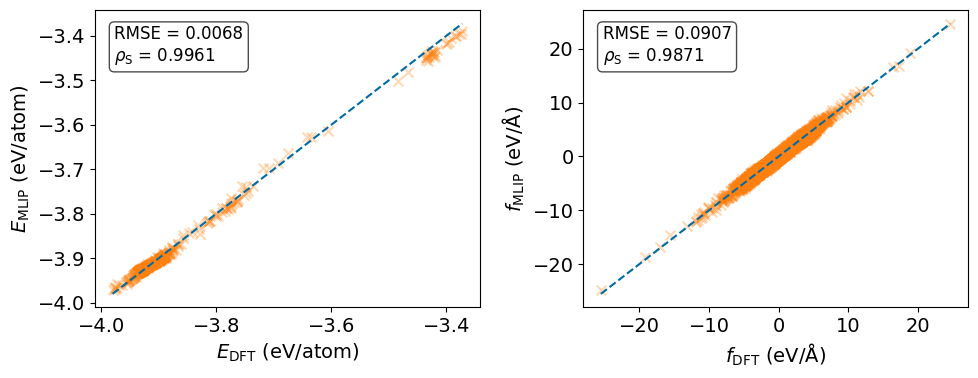

In [59]:
from mace.calculators import mace_mp
from tqdm.auto import tqdm

calc = mace_mp(model=pathlib.Path.cwd() / "trained_models" / "mp0_tuned_150_stagetwo_compiled.model")


from mace.calculators import MACECalculator
from tqdm.auto import tqdm

calc = MACECalculator(model_paths=[str(pathlib.Path.cwd() / "trained_models" / "mp0_tuned_150_stagetwo_compiled.model")])
pred_energies, pred_forces = evaluate_with_mace(calc, test_set)

print("Pareto plots for the fine-tuned small MP0 on test data:")

fig, axes = make_pareto_plots(
    ref_energies, ref_forces, pred_energies, pred_forces,
    save_to_this_file="fine-tuned-mp0_small.png",
)

### Tasks

Choose any or all of these tasks to try out the MACE training yourself.

1. Evaluate the test data with at least one other pre-trained [MACE FMLIP](https://mace-docs.readthedocs.io/en/latest/guide/foundation_models.html#foundation-models)<br>
   (a) Take into account what the different FMLIPs were trained on.<br>
   (b) But also what sizes are available.<br>
2. Calculate some different metrics and compare to the RMSE<br>
   (a) mean absolute error (MAE)<br>
   (b) mean squared error (MSE)<br>
4. Train from scratch and try<br>
   (a) different parameter choices (e.g., smaller `r_cut`, lopsided loss weights etc.)<br>
   (b) a 50:50 training / validation data split<br>
5. Most likely only feasible with a GPU:<br>
   Fine-tune any small FMLIP on<br>
   (a) even less data (50 training, 5 validation)<br>
   (b) 300 epochs (swa from 250)<br>

When choosing the `--freeze` setting, be aware that some of the newer FMLIPs have additional layers.

---

Example: energy-only loss

In [11]:
"""
    In 'real life' we often submit such trainings to HPC clusters.
    The command looks very much the same.
    The `subprocess` call is one option for training in a notebook.
"""
import getpass
import os
import subprocess

plotflag = True  # set to False if you do not want MACE to create the images

# uncomment this if you want to log to wandb.ai (separate account needed)
# if "WANDB_API_KEY" not in os.environ:
#    os.environ["WANDB_API_KEY"] = getpass.getpass("Enter your W&B API key: ")

wandb_entity = "ralfwan"  # your wandb.ai username
wandb_project = "aarhus_workshop"  # I can add you to this project if you want that
wandb_name = "cu2s_small_energy-only"

training_file = "subset_train_150.extxyz"
valid_file = "subset_valid_15.extxyz"

# these settings are as minimal as I dare to set them
result = subprocess.run([
    "mace_run_train",
    f"--name={wandb_name}",
    f"--model_dir={str(pathlib.Path.cwd() / 'trained_models')}",
    f"--work_dir={str(pathlib.Path.cwd() / 'training_output')}",
    f"--train_file={training_file}",
    f"--valid_file={valid_file}",
    "--E0s=average",
    "--energy_key=REF_energy",
    "--forces_weight=0.0",  # set the forces loss weight to 0.0
    "--model=ScaleShiftMACE",
    "--hidden_irreps=16x0e + 16x1o",
    "--r_max=6.0",
    "--max_ell=2",
    "--num_interactions=2",
    "--batch_size=4",
    "--max_num_epochs=50",
    f"--device={device}",
    "--seed=42",
    "--default_dtype=float32",
    "--ema",
    "--ema_decay=0.99",
    "--amsgrad",
    "--swa",
    "--start_swa=40",
    f"--plot={plotflag}",  # MACE will write figures to the work_dir if set to True
    "--wandb",
    f"--wandb_project={wandb_project}",
    f"--wandb_entity={wandb_entity}",
    f"--wandb_name={wandb_name}",
], capture_output=False)

/home/rwanzenboeck/Documents/theochem/workshops/202605_Aarhus/code/aarhus-dft-ml-workshop-2026/.venv/lib/python3.12/site-packages/e3nn/o3/_wigner.py:10: UserWarning: Environment variable TORCH_FORCE_NO_WEIGHTS_ONLY_LOAD detected, since the`weights_only` argument was not explicitly passed to `torch.load`, forcing weights_only=False.
  _Jd, _W3j_flat, _W3j_indices = torch.load(os.path.join(os.path.dirname(__file__), 'constants.pt'))


cuequivariance or cuequivariance_torch is not available. Cuequivariance acceleration will be disabled.
2026-05-01 16:45:28.802 INFO: ===========VERIFYING SETTINGS===========
2026-05-01 16:45:28.803 INFO: Stage Two is activated as start_stage_two was defined
2026-05-01 16:45:28.803 INFO: MACE version: 0.3.15
2026-05-01 16:45:28.849 INFO: CUDA version: 12.6, CUDA device: 0
2026-05-01 16:45:28.869 INFO: ===========LOADING INPUT DATA===========
2026-05-01 16:45:28.869 INFO: Using heads: ['Default']
2026-05-01 16:45:28.869 INFO: Using the key specifications to parse data:
2026-05-01 16:45:28.869 INFO: Default: KeySpecification(info_keys={'energy': 'REF_energy', 'stress': 'REF_stress', 'virials': 'REF_virials', 'dipole': 'dipole', 'head': 'head', 'elec_temp': 'elec_temp', 'total_charge': 'total_charge', 'polarizability': 'polarizability', 'total_spin': 'total_spin'}, arrays_keys={'forces': 'REF_forces', 'charges': 'REF_charges'})
2026-05-01 16:45:28.869 INFO: =============    Processing head

/home/rwanzenboeck/Documents/theochem/workshops/202605_Aarhus/code/aarhus-dft-ml-workshop-2026/miniforge3/envs/workshop_dependencies/lib/python3.12/ast.py:407: UserWarning: The TorchScript type system doesn't support instance-level annotations on empty non-base types in `__init__`. Instead, either 1) use a type annotation in the class body, or 2) wrap the type in `torch.jit.Attribute`.
  return visitor(node)
/home/rwanzenboeck/Documents/theochem/workshops/202605_Aarhus/code/aarhus-dft-ml-workshop-2026/miniforge3/envs/workshop_dependencies/lib/python3.12/ast.py:407: UserWarning: The TorchScript type system doesn't support instance-level annotations on empty non-base types in `__init__`. Instead, either 1) use a type annotation in the class body, or 2) wrap the type in `torch.jit.Attribute`.
  return visitor(node)
/home/rwanzenboeck/Documents/theochem/workshops/202605_Aarhus/code/aarhus-dft-ml-workshop-2026/miniforge3/envs/workshop_dependencies/lib/python3.12/ast.py:407: UserWarning: The

2026-05-01 16:45:29.852 INFO: ===========OPTIMIZER INFORMATION===========
2026-05-01 16:45:29.852 INFO: Using ADAM as parameter optimizer
2026-05-01 16:45:29.852 INFO: Batch size: 4
2026-05-01 16:45:29.852 INFO: Using Exponential Moving Average with decay: 0.99
2026-05-01 16:45:29.852 INFO: Number of gradient updates: 1875
2026-05-01 16:45:29.852 INFO: Learning rate: 0.01, weight decay: 5e-07
2026-05-01 16:45:29.852 INFO: WeightedEnergyForcesLoss(energy_weight=1.000, forces_weight=0.000)
2026-05-01 16:45:29.852 INFO: === Layer's learning rates ===
2026-05-01 16:45:29.852 INFO: Param group 0: lr = 0.01
2026-05-01 16:45:29.852 INFO: Param group 1: lr = 0.01
2026-05-01 16:45:29.852 INFO: Param group 2: lr = 0.01
2026-05-01 16:45:29.852 INFO: Param group 3: lr = 0.01
2026-05-01 16:45:29.852 INFO: Param group 4: lr = 0.01
2026-05-01 16:45:29.852 INFO: Stage Two (after 40 epochs) with loss function: WeightedEnergyForcesLoss(energy_weight=1000.000, forces_weight=100.000), with energy weight :

wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /home/rwanzenboeck/.netrc.
wandb: Currently logged in as: ralfwan to https://api.wandb.ai. Use `wandb login --relogin` to force relogin
wandb: setting up run naco7dtj
wandb: Tracking run with wandb version 0.26.1
wandb: Run data is saved locally in /home/rwanzenboeck/Documents/theochem/workshops/202605_Aarhus/code/aarhus-dft-ml-workshop-2026/notebooks/MLIP/wandb/run-20260501_164530-naco7dtj
wandb: Run `wandb offline` to turn off syncing.
wandb: Syncing run cu2s_small_energy-only
wandb: ⭐️ View project at https://wandb.ai/ralfwan/aarhus_workshop
wandb: 🚀 View run at https://wandb.ai/ralfwan/aarhus_workshop/runs/naco7dtj


2026-05-01 16:45:32.108 INFO: Using gradient clipping with tolerance=10.000
2026-05-01 16:45:32.108 INFO: 
2026-05-01 16:45:32.108 INFO: ===========TRAINING===========
2026-05-01 16:45:32.109 INFO: Started training, reporting errors on validation set
2026-05-01 16:45:32.109 INFO: Loss metrics on validation set
2026-05-01 16:45:32.664 INFO: Initial: head: Default, loss=0.01786119, RMSE_E_per_atom=  339.78 meV, RMSE_F=  846.01 meV / A
2026-05-01 16:45:37.123 INFO: Epoch 0: head: Default, loss=0.00403923, RMSE_E_per_atom=  146.27 meV, RMSE_F=  843.17 meV / A
2026-05-01 16:45:41.000 INFO: Epoch 1: head: Default, loss=0.00324508, RMSE_E_per_atom=  134.28 meV, RMSE_F=  840.51 meV / A
2026-05-01 16:45:44.377 INFO: Epoch 2: head: Default, loss=0.00196424, RMSE_E_per_atom=  104.13 meV, RMSE_F=  832.11 meV / A
2026-05-01 16:45:47.702 INFO: Epoch 3: head: Default, loss=0.00040731, RMSE_E_per_atom=   49.36 meV, RMSE_F=  952.85 meV / A
2026-05-01 16:45:50.945 INFO: Epoch 4: head: Default, loss=0.00

/home/rwanzenboeck/Documents/theochem/workshops/202605_Aarhus/code/aarhus-dft-ml-workshop-2026/.venv/lib/python3.12/site-packages/mace/tools/checkpoint.py:187: UserWarning: Environment variable TORCH_FORCE_NO_WEIGHTS_ONLY_LOAD detected, since the`weights_only` argument was not explicitly passed to `torch.load`, forcing weights_only=False.
  torch.load(f=checkpoint_info.path, map_location=device),
/home/rwanzenboeck/Documents/theochem/workshops/202605_Aarhus/code/aarhus-dft-ml-workshop-2026/miniforge3/envs/workshop_dependencies/lib/python3.12/ast.py:407: UserWarning: The TorchScript type system doesn't support instance-level annotations on empty non-base types in `__init__`. Instead, either 1) use a type annotation in the class body, or 2) wrap the type in `torch.jit.Attribute`.
  return visitor(node)


2026-05-01 16:48:24.069 INFO: Computing metrics for training, validation, and test sets
2026-05-01 16:48:24.070 INFO: Skipping evaluation for heads: ['pt_head']
2026-05-01 16:48:24.070 INFO: Evaluating train_Default ...
2026-05-01 16:48:25.370 INFO: Evaluating valid_Default ...
2026-05-01 16:48:25.507 INFO: Error-table on TRAIN and VALID:
+---------------+---------------------+------------------+-------------------+
|  config_type  | RMSE E / meV / atom | RMSE F / meV / A | relative F RMSE % |
+---------------+---------------------+------------------+-------------------+
| train_Default |            9.8      |        726.4     |         84.38     |
| valid_Default |            9.1      |        678.3     |         80.45     |
+---------------+---------------------+------------------+-------------------+
2026-05-01 16:48:28.386 INFO: Loading checkpoint: /home/rwanzenboeck/Documents/theochem/workshops/202605_Aarhus/code/aarhus-dft-ml-workshop-2026/notebooks/MLIP/training_output/checkpoin

/home/rwanzenboeck/Documents/theochem/workshops/202605_Aarhus/code/aarhus-dft-ml-workshop-2026/.venv/lib/python3.12/site-packages/mace/tools/checkpoint.py:187: UserWarning: Environment variable TORCH_FORCE_NO_WEIGHTS_ONLY_LOAD detected, since the`weights_only` argument was not explicitly passed to `torch.load`, forcing weights_only=False.
  torch.load(f=checkpoint_info.path, map_location=device),
/home/rwanzenboeck/Documents/theochem/workshops/202605_Aarhus/code/aarhus-dft-ml-workshop-2026/miniforge3/envs/workshop_dependencies/lib/python3.12/ast.py:407: UserWarning: The TorchScript type system doesn't support instance-level annotations on empty non-base types in `__init__`. Instead, either 1) use a type annotation in the class body, or 2) wrap the type in `torch.jit.Attribute`.
  return visitor(node)


2026-05-01 16:48:28.827 INFO: Computing metrics for training, validation, and test sets
2026-05-01 16:48:28.827 INFO: Skipping evaluation for heads: ['pt_head']
2026-05-01 16:48:28.828 INFO: Evaluating train_Default ...
2026-05-01 16:48:30.077 INFO: Evaluating valid_Default ...
2026-05-01 16:48:30.198 INFO: Error-table on TRAIN and VALID:
+---------------+---------------------+------------------+-------------------+
|  config_type  | RMSE E / meV / atom | RMSE F / meV / A | relative F RMSE % |
+---------------+---------------------+------------------+-------------------+
| train_Default |            9.8      |        250.6     |         28.12     |
| valid_Default |           11.0      |        241.1     |         28.59     |
+---------------+---------------------+------------------+-------------------+
2026-05-01 16:48:32.509 INFO: Done
wandb: 
wandb: 🚀 View run cu2s_small_energy-only at: https://wandb.ai/ralfwan/aarhus_workshop/runs/naco7dtj
wandb: Find logs at: wandb/run-20260501_16

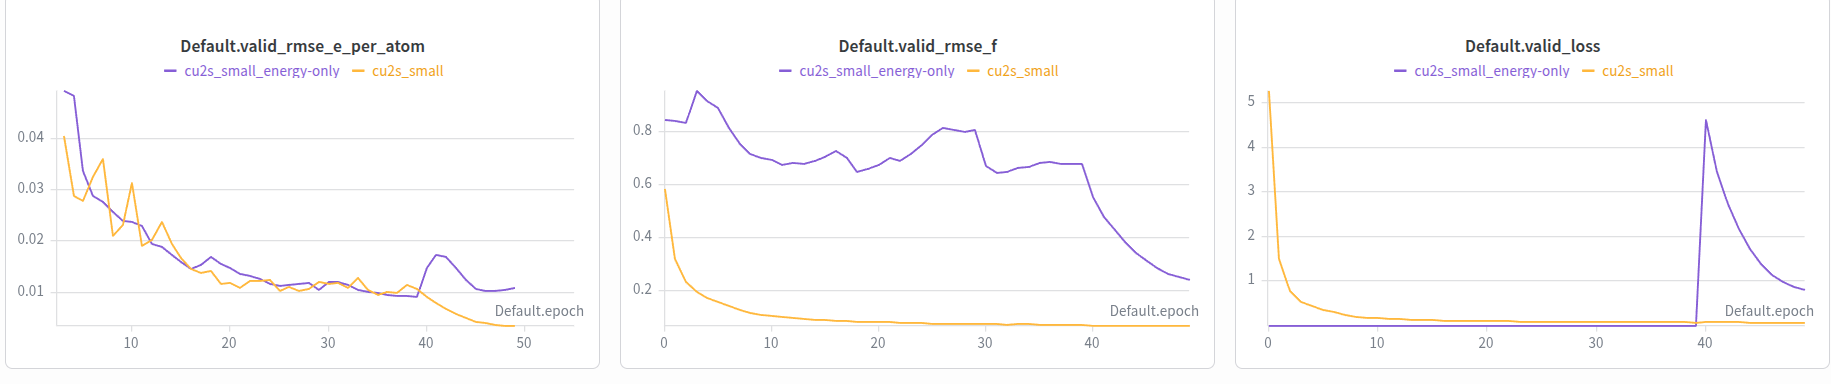